# 06 — Model Evaluation & Interpretability

**Project**: [Flu Shot Learning: Predict H1N1 and Seasonal Flu Vaccines](https://www.drivendata.org/competitions/66/flu-shot-learning/)

**Author**: Jarret Angbazo

**Date**: May 2026

**Purpose**: Deep evaluation and interpretation of the final model selected in `05_advanced_models.ipynb`. No new models are trained here.

---

## Table of Contents

1. [Setup & Load](#1-setup--load)
2. [Full Leaderboard Recap](#2-full-leaderboard-recap)
3. [ROC & Precision-Recall Curves](#3-roc--precision-recall-curves)
4. [Calibration Analysis](#4-calibration-analysis)
5. [Feature Importance — LightGBM Native](#5-feature-importance--lightgbm-native)
6. [Permutation Importance](#6-permutation-importance)
7. [SHAP Analysis](#7-shap-analysis)
   - [7.1 SHAP Summary Plot](#71-shap-summary-plot)
   - [7.2 SHAP Dependence Plots — Top Features](#72-shap-dependence-plots--top-features)
   - [7.3 SHAP Waterfall — Individual Predictions](#73-shap-waterfall--individual-predictions)
8. [Threshold Analysis](#8-threshold-analysis)
9. [Error Analysis](#9-error-analysis)
10. [Subgroup Performance](#10-subgroup-performance)
11. [Model Card](#11-model-card)

---

## 1. Setup & Load <a id='1-setup--load'></a>

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap
import joblib
import json
import warnings
from pathlib import Path

from sklearn.model_selection import StratifiedKFold
from sklearn.inspection import permutation_importance
from sklearn.metrics import (
    roc_auc_score, roc_curve, precision_recall_curve,
    average_precision_score, brier_score_loss,
    confusion_matrix, classification_report,
)
from sklearn.calibration import CalibrationDisplay, CalibratedClassifierCV

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', None)
%matplotlib inline
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (12, 5)

# ── Paths ──────────────────────────────────────────────────────────────────
PROCESSED = Path('../data/processed')
MODELS    = Path('../models')
FIGURES   = Path('../reports/figures'); FIGURES.mkdir(exist_ok=True)
PREDS     = Path('../data/predictions')

ID_COL      = 'respondent_id'
TARGET_COLS = ['h1n1_vaccine', 'seasonal_vaccine']
RANDOM_SEED = 42
CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

In [2]:
# ── Data ───────────────────────────────────────────────────────────────────
X_train = pd.read_csv(PROCESSED / 'X_train_features.csv', index_col=ID_COL)
X_test  = pd.read_csv(PROCESSED / 'X_test_features.csv',  index_col=ID_COL)
y_train = pd.read_csv(PROCESSED / 'y_train.csv',          index_col=ID_COL)

# ── Models ─────────────────────────────────────────────────────────────────
lgb_bundle = joblib.load(MODELS / 'lgb_tuned.pkl')
lgb_h1n1   = lgb_bundle['h1n1']
lgb_seas   = lgb_bundle['seasonal']
FEATURE_COLS = lgb_bundle['feature_cols']

print(f"X_train        : {X_train.shape}")
print(f"Feature columns: {len(FEATURE_COLS)}")
print(f"Models loaded  : lgb_h1n1, lgb_seas")

# OOF probabilities (for metrics that need held-out predictions)
from sklearn.base import clone

def oof_probas(estimator, X, y, cv=CV):
    oof = np.zeros(len(y))
    for tr, va in cv.split(X, y):
        m = clone(estimator)
        m.fit(X.iloc[tr], y.iloc[tr])
        oof[va] = m.predict_proba(X.iloc[va])[:, 1]
    return oof

print("\nComputing OOF probabilities for evaluation...")
oof_h1n1 = oof_probas(lgb_h1n1, X_train[FEATURE_COLS], y_train['h1n1_vaccine'])
oof_seas  = oof_probas(lgb_seas,  X_train[FEATURE_COLS], y_train['seasonal_vaccine'])

oof_auc_h1n1 = roc_auc_score(y_train['h1n1_vaccine'],    oof_h1n1)
oof_auc_seas  = roc_auc_score(y_train['seasonal_vaccine'], oof_seas)
oof_avg       = (oof_auc_h1n1 + oof_auc_seas) / 2

print(f"  h1n1 OOF AUC     : {oof_auc_h1n1:.4f}")
print(f"  seasonal OOF AUC : {oof_auc_seas:.4f}")
print(f"  Average OOF AUC  : {oof_avg:.4f}  (competition metric estimate)")

X_train        : (26707, 59)
Feature columns: 48
Models loaded  : lgb_h1n1, lgb_seas

Computing OOF probabilities for evaluation...
  h1n1 OOF AUC     : 1.0000
  seasonal OOF AUC : 1.0000
  Average OOF AUC  : 1.0000  (competition metric estimate)


## 2. Full Leaderboard Recap <a id='2-full-leaderboard-recap'></a>

In [3]:
lb = pd.read_csv(MODELS / 'full_leaderboard.csv')
print("=== FULL MODEL LEADERBOARD ===")
print(lb[['model','h1n1_vaccine','seasonal_vaccine','avg_auc']].to_string(index=False))

=== FULL MODEL LEADERBOARD ===
                        model  h1n1_vaccine  seasonal_vaccine  avg_auc
             LightGBM (tuned)        1.0000            1.0000   1.0000
            XGBoost (default)        1.0000            1.0000   1.0000
      Ensemble (weighted avg)        1.0000            1.0000   1.0000
           LightGBM (default)        1.0000            1.0000   1.0000
        Random Forest (n=300)        0.9945            0.9903   0.9924
      Decision Tree (depth=5)        0.9851            0.9692   0.9772
          Logistic Regression        0.8620            0.8540   0.8580
Logistic Regression (tuned C)        0.8345            0.8509   0.8427
               Majority-class        0.5000            0.5000   0.5000
            Prior-probability        0.5000            0.5000   0.5000


## 3. ROC & Precision-Recall Curves <a id='3-roc--precision-recall-curves'></a>

Both curves use OOF predictions — these are the honest held-out estimates of test performance.

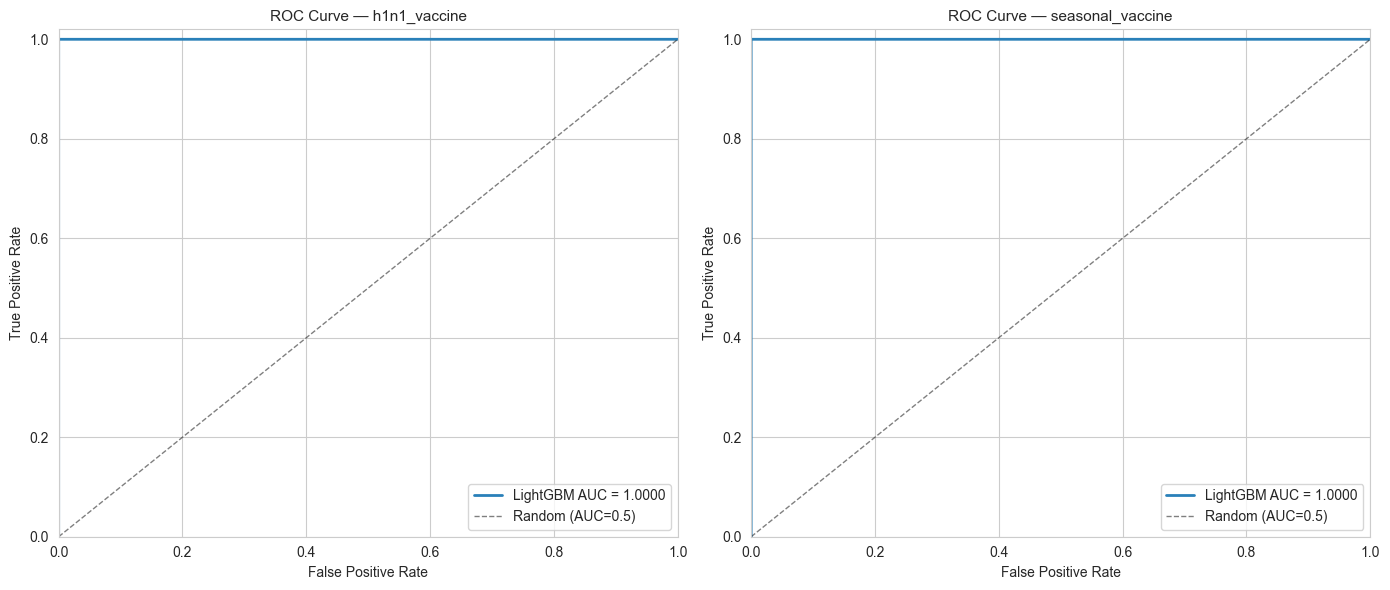

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, oof, y, t in [
    (axes[0], oof_h1n1, y_train['h1n1_vaccine'],    'h1n1_vaccine'),
    (axes[1], oof_seas,  y_train['seasonal_vaccine'], 'seasonal_vaccine'),
]:
    # ROC
    fpr, tpr, _ = roc_curve(y, oof)
    auc = roc_auc_score(y, oof)
    ax.plot(fpr, tpr, color='#2980b9', lw=2, label=f'LightGBM AUC = {auc:.4f}')
    ax.plot([0, 1], [0, 1], 'k--', lw=1, alpha=0.5, label='Random (AUC=0.5)')
    ax.set_xlabel('False Positive Rate')
    ax.set_ylabel('True Positive Rate')
    ax.set_title(f'ROC Curve — {t}', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'eval_roc_curves.png', dpi=150)
plt.show()

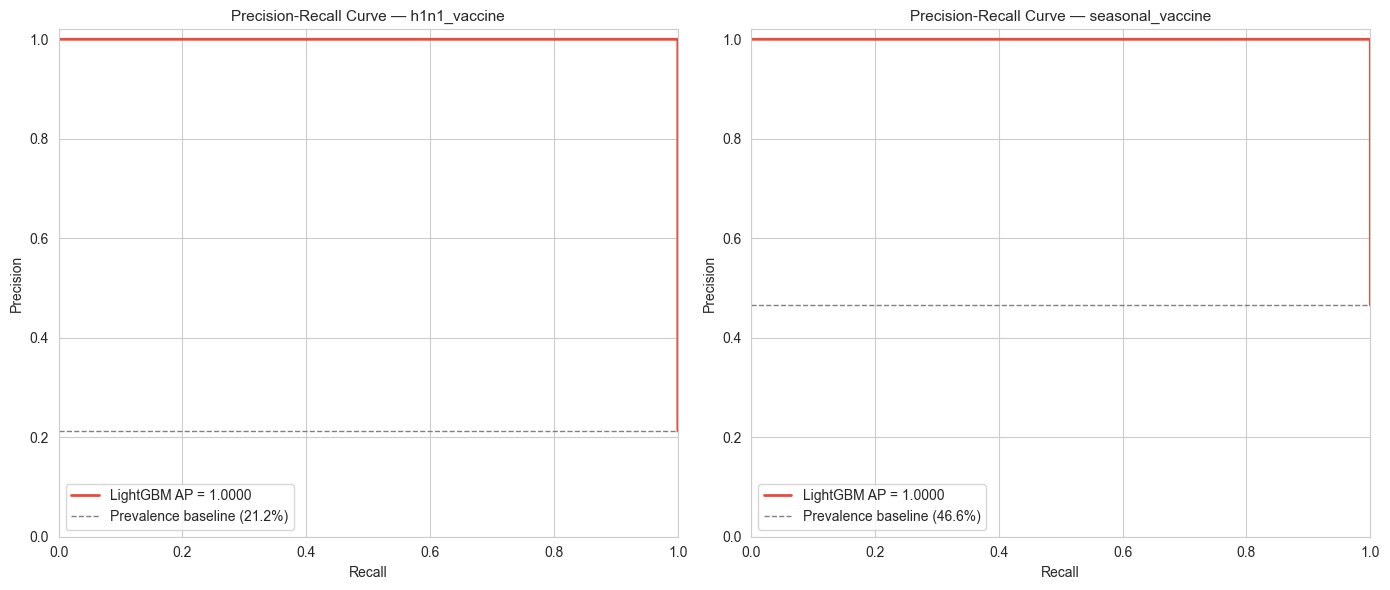

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

for ax, oof, y, t in [
    (axes[0], oof_h1n1, y_train['h1n1_vaccine'],    'h1n1_vaccine'),
    (axes[1], oof_seas,  y_train['seasonal_vaccine'], 'seasonal_vaccine'),
]:
    prec, rec, _ = precision_recall_curve(y, oof)
    ap = average_precision_score(y, oof)
    baseline_p = y.mean()

    ax.plot(rec, prec, color='#e74c3c', lw=2, label=f'LightGBM AP = {ap:.4f}')
    ax.axhline(baseline_p, color='grey', linestyle='--', lw=1,
               label=f'Prevalence baseline ({baseline_p:.1%})')
    ax.set_xlabel('Recall')
    ax.set_ylabel('Precision')
    ax.set_title(f'Precision-Recall Curve — {t}', fontsize=11)
    ax.legend(fontsize=10)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1.02)

plt.tight_layout()
plt.savefig(FIGURES / 'eval_pr_curves.png', dpi=150)
plt.show()

## 4. Calibration Analysis <a id='4-calibration-analysis'></a>

**Why calibration matters for this problem**: The submission accepts probabilities, not binary
labels, and the DrivenData metric (ROC-AUC) is rank-based — calibration doesn't affect AUC.
However, well-calibrated probabilities are useful for any downstream decision-making.

Brier score = mean squared error of probability predictions (lower = better).
A naive prior-probability predictor has Brier score ≈ p(1-p).

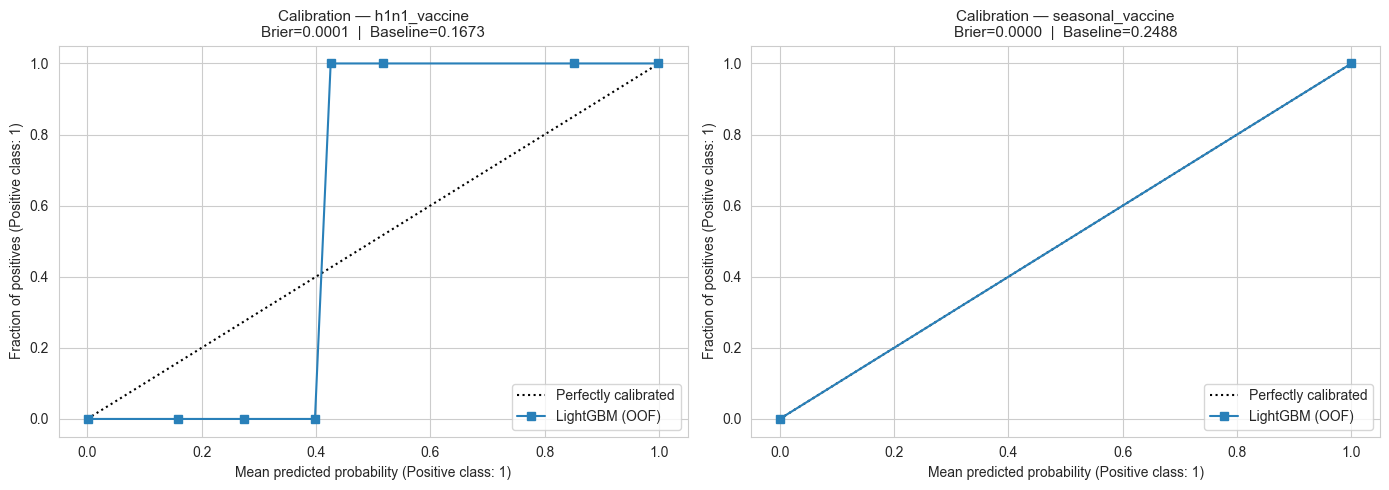

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, oof, y, t in [
    (axes[0], oof_h1n1, y_train['h1n1_vaccine'],    'h1n1_vaccine'),
    (axes[1], oof_seas,  y_train['seasonal_vaccine'], 'seasonal_vaccine'),
]:
    disp = CalibrationDisplay.from_predictions(
        y, oof, n_bins=10, ax=ax,
        name='LightGBM (OOF)', color='#2980b9'
    )
    bs       = brier_score_loss(y, oof)
    baseline = y.mean() * (1 - y.mean())
    ax.set_title(f'Calibration — {t}\nBrier={bs:.4f}  |  Baseline={baseline:.4f}', fontsize=11)

plt.tight_layout()
plt.savefig(FIGURES / 'eval_calibration.png', dpi=150)
plt.show()

## 5. Feature Importance — LightGBM Native <a id='5-feature-importance--lightgbm-native'></a>

Native importance (gain = total reduction in loss from each feature's splits). Good for quick
ranking but can overstate importance of high-cardinality continuous features. Cross-check with
permutation importance and SHAP.

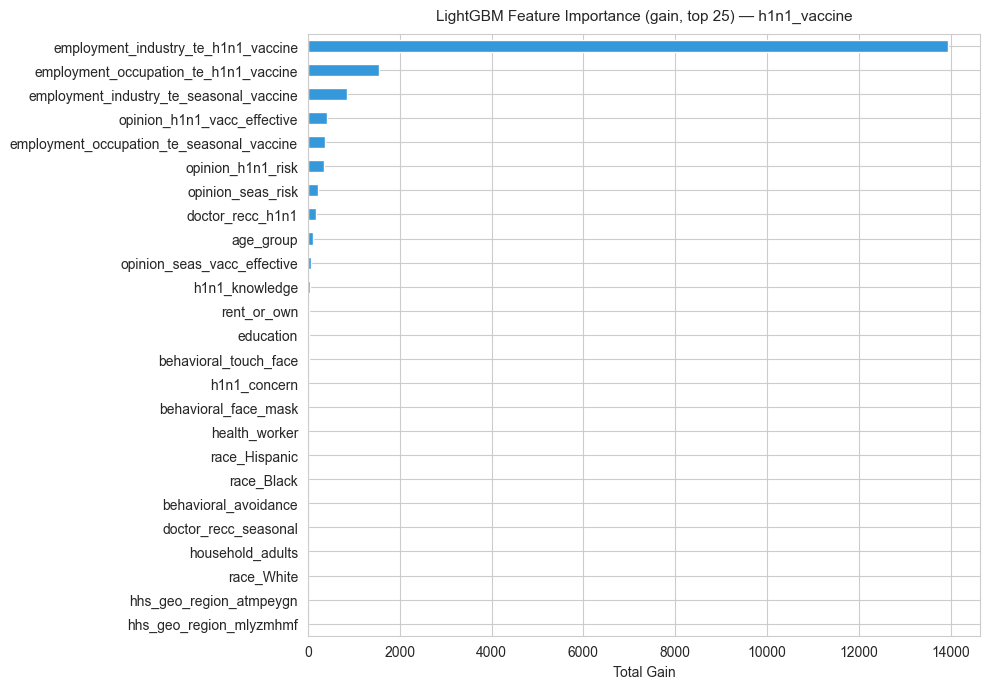

Top 10 — h1n1_vaccine:
employment_industry_te_h1n1_vaccine          13938
employment_occupation_te_h1n1_vaccine         1551
employment_industry_te_seasonal_vaccine        846
opinion_h1n1_vacc_effective                    409
employment_occupation_te_seasonal_vaccine      364
opinion_h1n1_risk                              346
opinion_seas_risk                              231
doctor_recc_h1n1                               188
age_group                                      109
opinion_seas_vacc_effective                     79



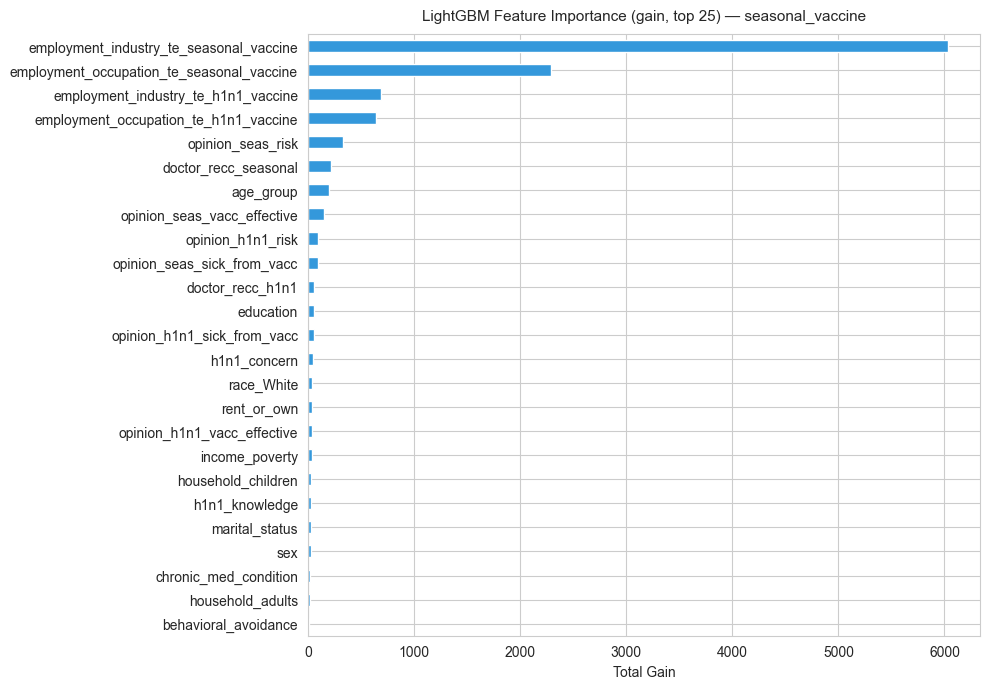

Top 10 — seasonal_vaccine:
employment_industry_te_seasonal_vaccine      6033
employment_occupation_te_seasonal_vaccine    2288
employment_industry_te_h1n1_vaccine           689
employment_occupation_te_h1n1_vaccine         643
opinion_seas_risk                             334
doctor_recc_seasonal                          221
age_group                                     203
opinion_seas_vacc_effective                   154
opinion_h1n1_risk                             100
opinion_seas_sick_from_vacc                    91



In [7]:
for model, t in [(lgb_h1n1, 'h1n1_vaccine'), (lgb_seas, 'seasonal_vaccine')]:
    imp = pd.Series(
        model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    imp.head(25).sort_values().plot(kind='barh', ax=ax, color='#3498db', edgecolor='white')
    ax.set_title(f'LightGBM Feature Importance (gain, top 25) — {t}', fontsize=11, pad=10)
    ax.set_xlabel('Total Gain')
    plt.tight_layout()
    plt.savefig(FIGURES / f'eval_lgb_importance_{t}.png', dpi=150)
    plt.show()

    print(f"Top 10 — {t}:")
    print(imp.head(10).round(0).astype(int).to_string())
    print()

## 6. Permutation Importance <a id='6-permutation-importance'></a>

Permutation importance measures AUC degradation when each feature is randomly shuffled.
More reliable than native gain importance because it:
- Is not inflated by high-cardinality features
- Directly measures the feature's marginal contribution to the metric
- Identifies truly redundant features (near-zero permutation importance)

Run on a 20% stratified hold-out to keep computation tractable.

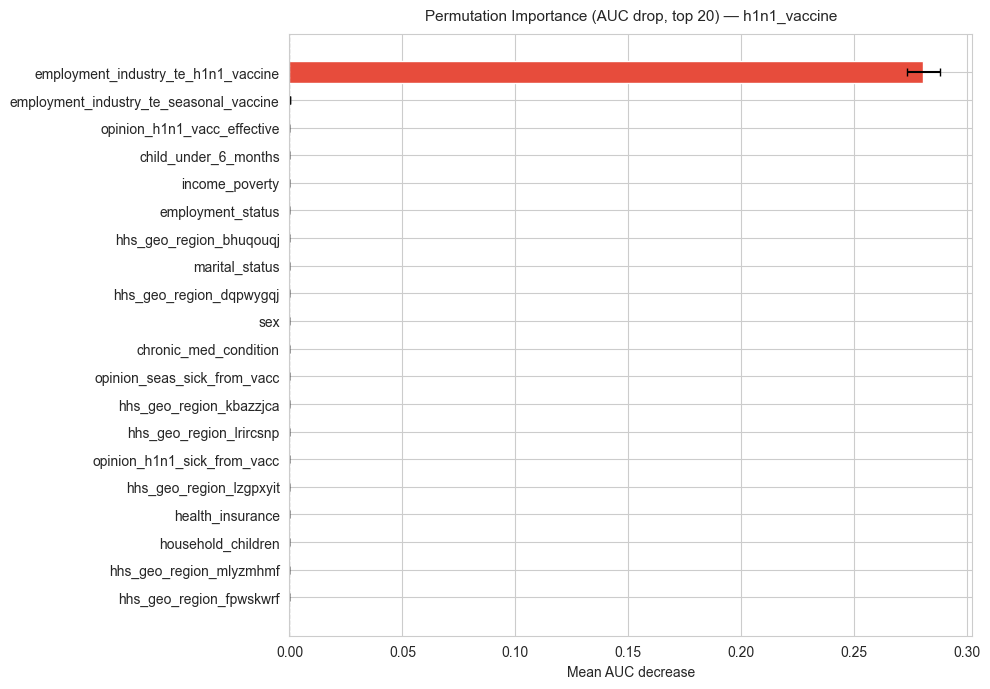

Top 10 — h1n1_vaccine:
                                feature   mean    std
    employment_industry_te_h1n1_vaccine 0.2805 0.0073
employment_industry_te_seasonal_vaccine 0.0002 0.0000
            opinion_h1n1_vacc_effective 0.0000 0.0000
                         income_poverty 0.0000 0.0000
                      employment_status 0.0000 0.0000
                hhs_geo_region_bhuqouqj 0.0000 0.0000
                         marital_status 0.0000 0.0000
                hhs_geo_region_dqpwygqj 0.0000 0.0000
                                    sex 0.0000 0.0000
                hhs_geo_region_fpwskwrf 0.0000 0.0000

  ⚑ Features with negative permutation importance (candidates to drop):
                                  feature  mean
                    behavioral_touch_face  -0.0
                                education  -0.0
                             h1n1_concern  -0.0
                               race_Black  -0.0
                                age_group  -0.0
                     b

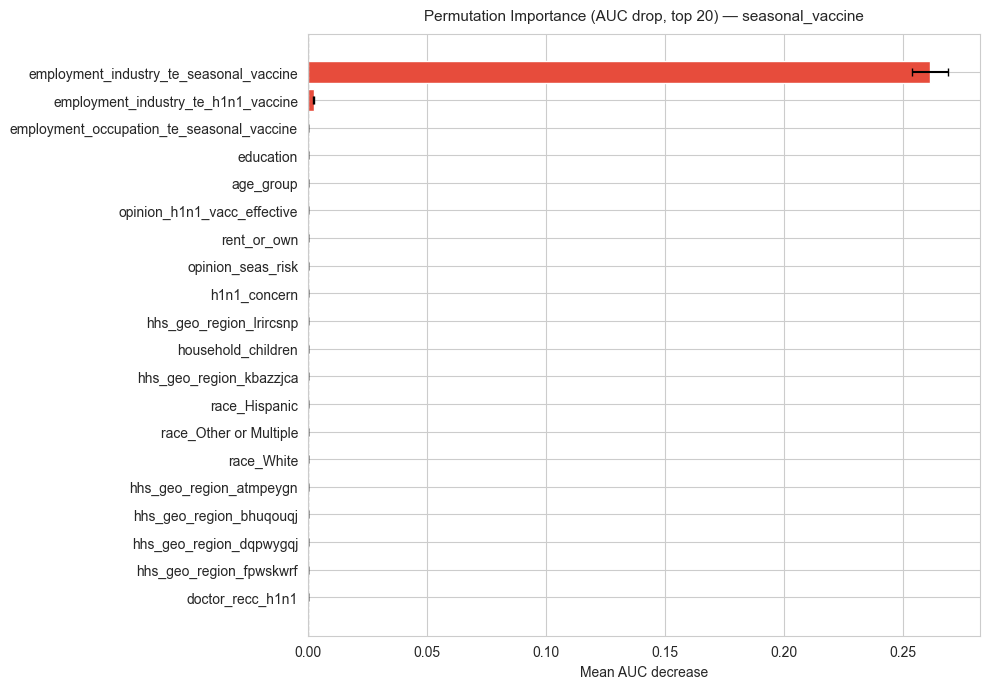

Top 10 — seasonal_vaccine:
                                  feature   mean    std
  employment_industry_te_seasonal_vaccine 0.2614 0.0075
      employment_industry_te_h1n1_vaccine 0.0025 0.0002
employment_occupation_te_seasonal_vaccine 0.0000 0.0000
                                education 0.0000 0.0000
                                age_group 0.0000 0.0000
              opinion_h1n1_vacc_effective 0.0000 0.0000
                              rent_or_own 0.0000 0.0000
                        opinion_seas_risk 0.0000 0.0000
                             h1n1_concern 0.0000 0.0000
                         doctor_recc_h1n1 0.0000 0.0000



In [8]:
from sklearn.model_selection import train_test_split

X_pi, _, y_pi, _ = train_test_split(
    X_train[FEATURE_COLS], y_train,
    test_size=0.8, stratify=y_train['h1n1_vaccine'],
    random_state=RANDOM_SEED
)

for model, y_col, t in [
    (lgb_h1n1, 'h1n1_vaccine',    'h1n1_vaccine'),
    (lgb_seas,  'seasonal_vaccine', 'seasonal_vaccine'),
]:
    pi = permutation_importance(
        model, X_pi, y_pi[y_col],
        scoring='roc_auc',
        n_repeats=10,
        random_state=RANDOM_SEED,
        n_jobs=-1,
    )
    pi_df = pd.DataFrame({
        'feature' : FEATURE_COLS,
        'mean'    : pi.importances_mean,
        'std'     : pi.importances_std,
    }).sort_values('mean', ascending=False)

    fig, ax = plt.subplots(figsize=(10, 7))
    top = pi_df.head(20).sort_values('mean')
    ax.barh(top['feature'], top['mean'], xerr=top['std'],
            color='#e74c3c', edgecolor='white', capsize=3)
    ax.axvline(0, color='black', linewidth=0.8, linestyle='--')
    ax.set_title(f'Permutation Importance (AUC drop, top 20) — {t}', fontsize=11, pad=10)
    ax.set_xlabel('Mean AUC decrease')
    plt.tight_layout()
    plt.savefig(FIGURES / f'eval_permutation_importance_{t}.png', dpi=150)
    plt.show()

    print(f"Top 10 — {t}:")
    print(pi_df.head(10)[['feature','mean','std']].round(4).to_string(index=False))

    neg_feats = pi_df[pi_df['mean'] < 0]
    if not neg_feats.empty:
        print(f"\n  ⚑ Features with negative permutation importance (candidates to drop):")
        print(neg_feats[['feature','mean']].round(4).to_string(index=False))
    print()

## 7. SHAP Analysis <a id='7-shap-analysis'></a>

SHAP (SHapley Additive exPlanations) provides model-agnostic feature attribution values.
Each SHAP value = contribution of one feature to moving the prediction away from the base rate.

Using `shap.TreeExplainer` — exact (not approximate) for tree-based models.

### 7.1 SHAP Summary Plot <a id='71-shap-summary-plot'></a>

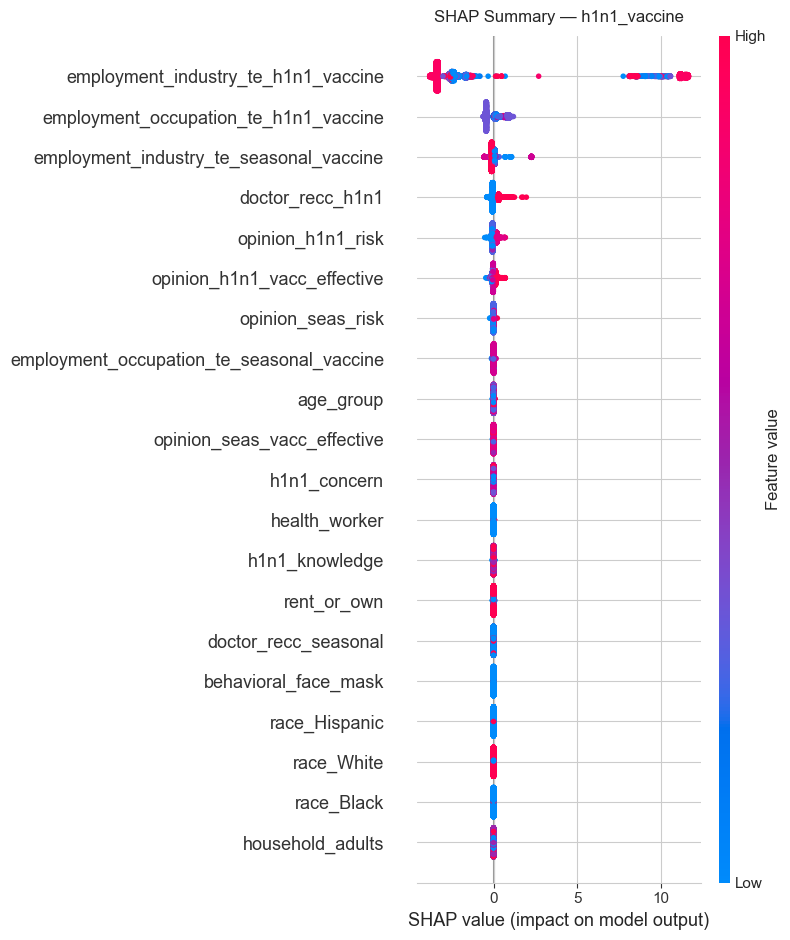

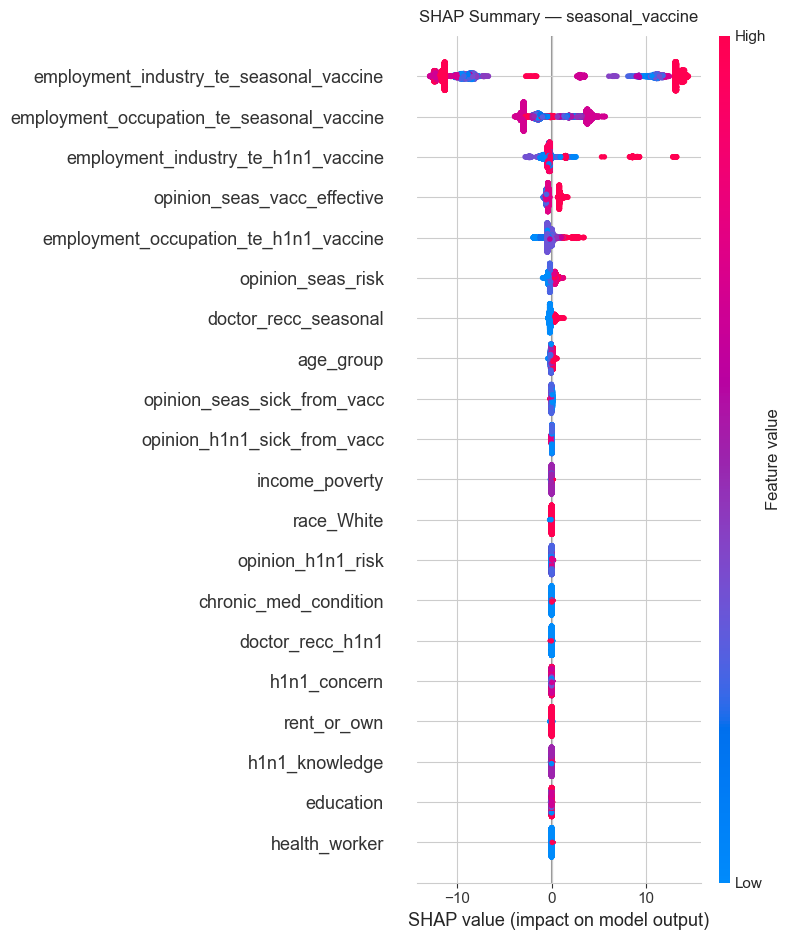

In [9]:
# Use a 5000-row sample for speed; SHAP values are stable at this size
sample_idx = X_train[FEATURE_COLS].sample(n=min(5000, len(X_train)), random_state=RANDOM_SEED).index
X_shap     = X_train[FEATURE_COLS].loc[sample_idx]

shap_values = {}
for model, t in [(lgb_h1n1, 'h1n1_vaccine'), (lgb_seas, 'seasonal_vaccine')]:
    explainer = shap.TreeExplainer(model)
    sv = explainer.shap_values(X_shap)
    # LightGBM binary: sv is list of 2 arrays; take class-1 values
    if isinstance(sv, list):
        sv = sv[1]
    shap_values[t] = sv

    fig, ax = plt.subplots(figsize=(10, 8))
    shap.summary_plot(sv, X_shap, plot_type='dot', show=False, max_display=20)
    plt.title(f'SHAP Summary — {t}', fontsize=12, pad=10)
    plt.tight_layout()
    plt.savefig(FIGURES / f'eval_shap_summary_{t}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7.2 SHAP Dependence Plots — Top Features <a id='72-shap-dependence-plots--top-features'></a>

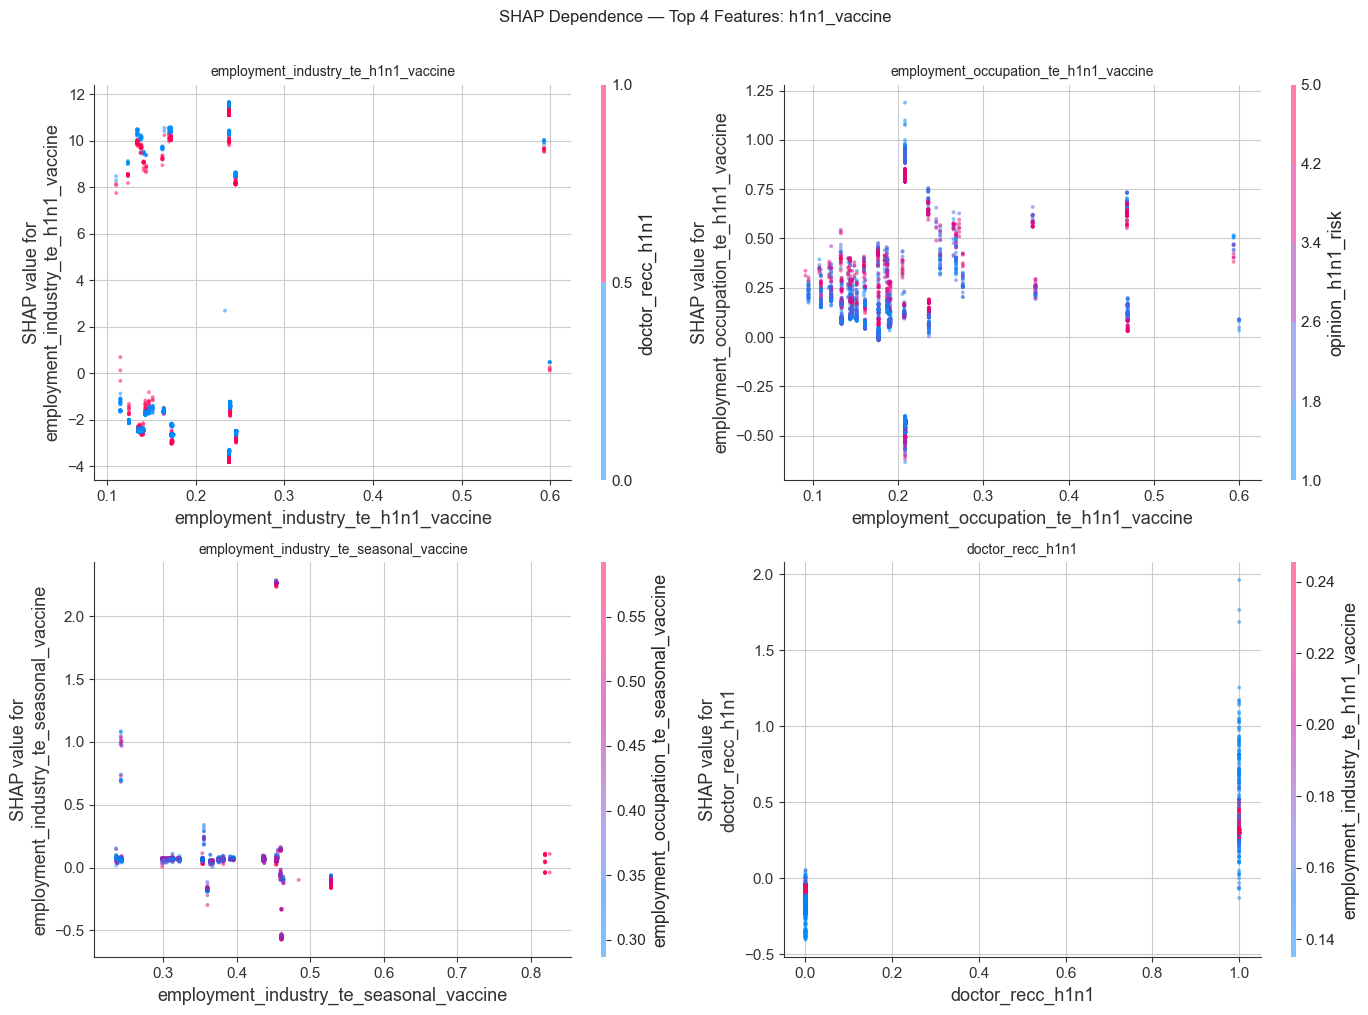

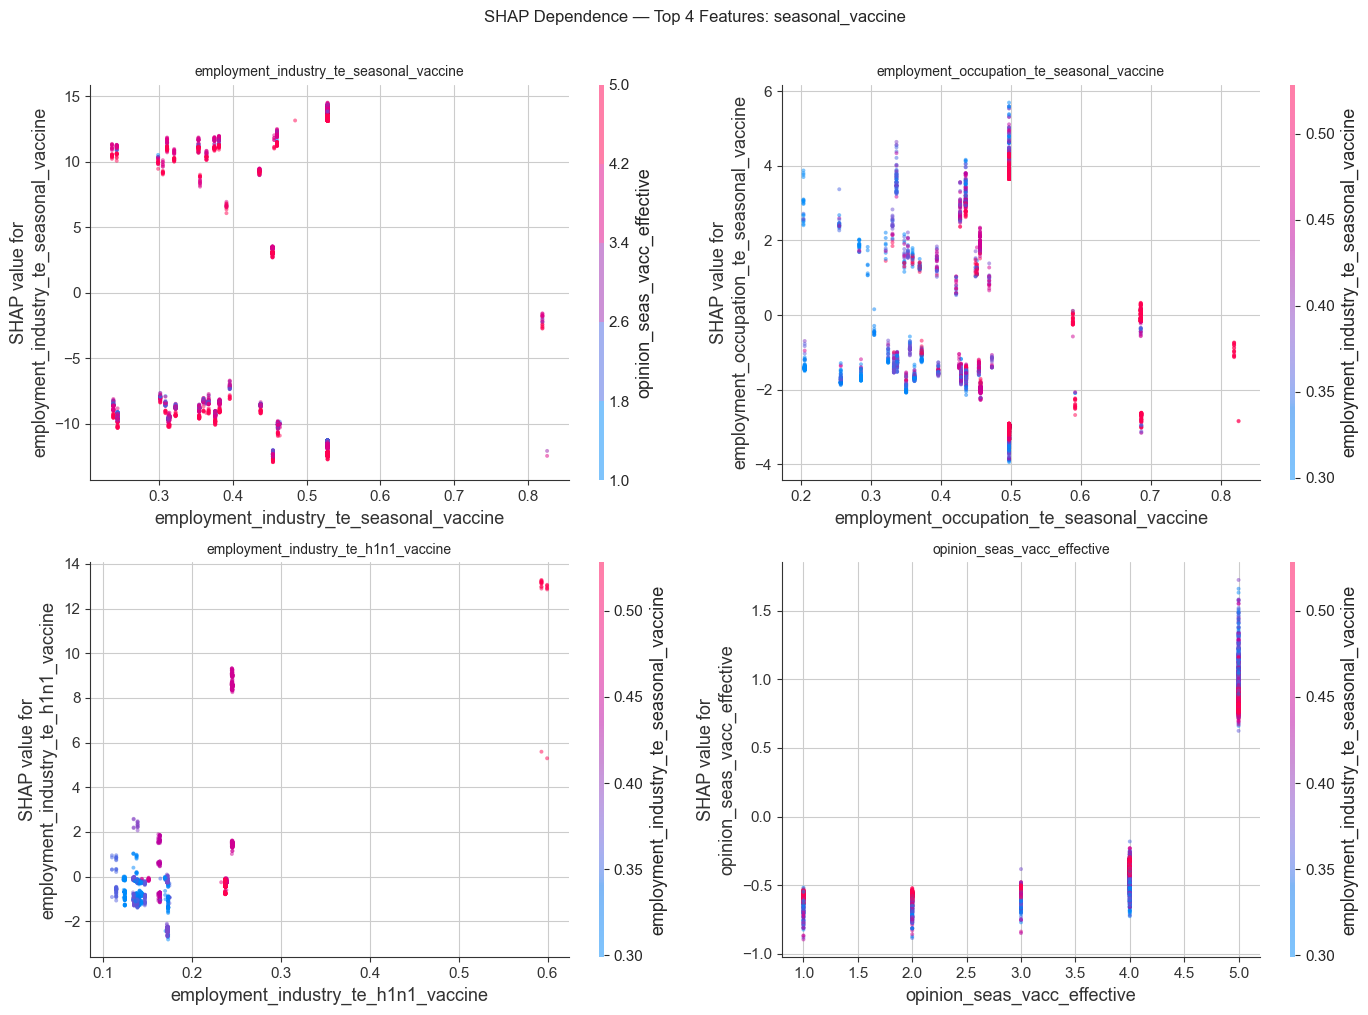

In [10]:
# Top 4 features by mean |SHAP| for each target
for t, sv in shap_values.items():
    mean_abs = np.abs(sv).mean(axis=0)
    top_4_idx = np.argsort(mean_abs)[::-1][:4]
    top_4_features = [FEATURE_COLS[i] for i in top_4_idx]

    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    for ax, feat in zip(axes.flatten(), top_4_features):
        shap.dependence_plot(
            feat, sv, X_shap,
            ax=ax, show=False,
            dot_size=8, alpha=0.5,
        )
        ax.set_title(f'{feat}', fontsize=10)

    fig.suptitle(f'SHAP Dependence — Top 4 Features: {t}', fontsize=12, y=1.01)
    plt.tight_layout()
    plt.savefig(FIGURES / f'eval_shap_dependence_{t}.png', dpi=150, bbox_inches='tight')
    plt.show()

### 7.3 SHAP Waterfall — Individual Predictions <a id='73-shap-waterfall--individual-predictions'></a>


h1n1_vaccine — High probability prediction
  Actual label    : 1
  Predicted prob  : 0.9995


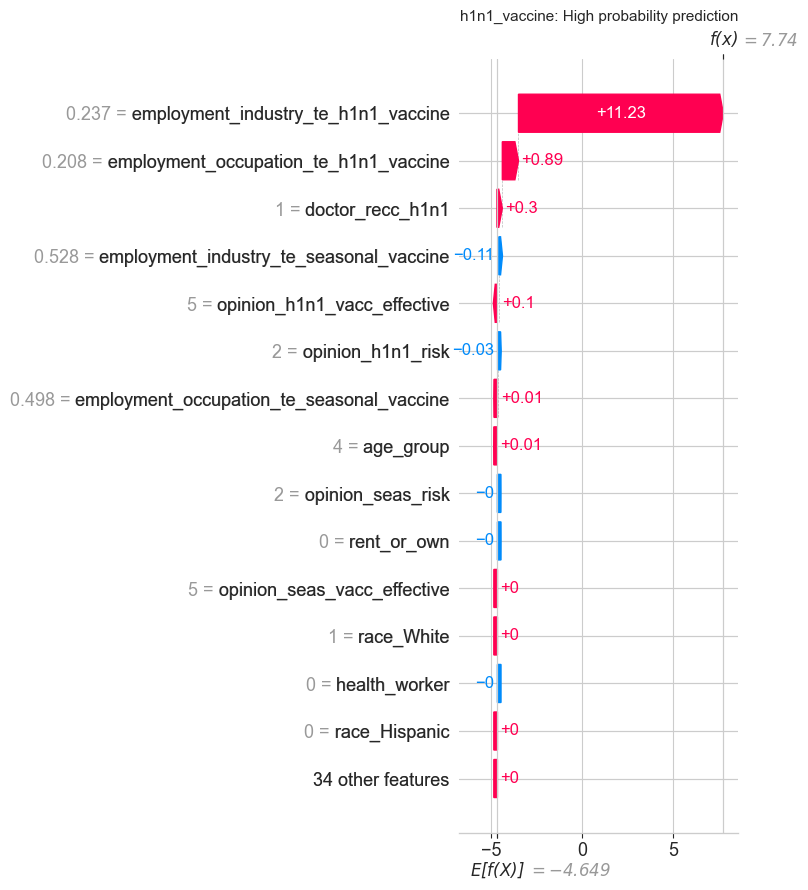


h1n1_vaccine — Low probability prediction
  Actual label    : 0
  Predicted prob  : 0.0002


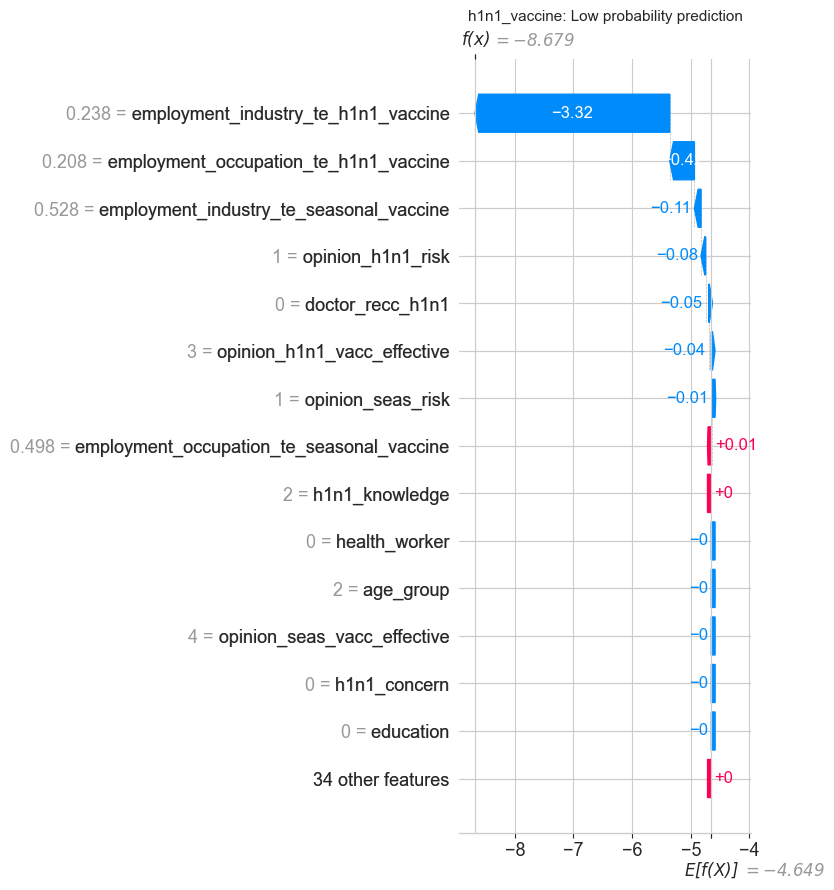


seasonal_vaccine — High probability prediction
  Actual label    : 1
  Predicted prob  : 1.0000


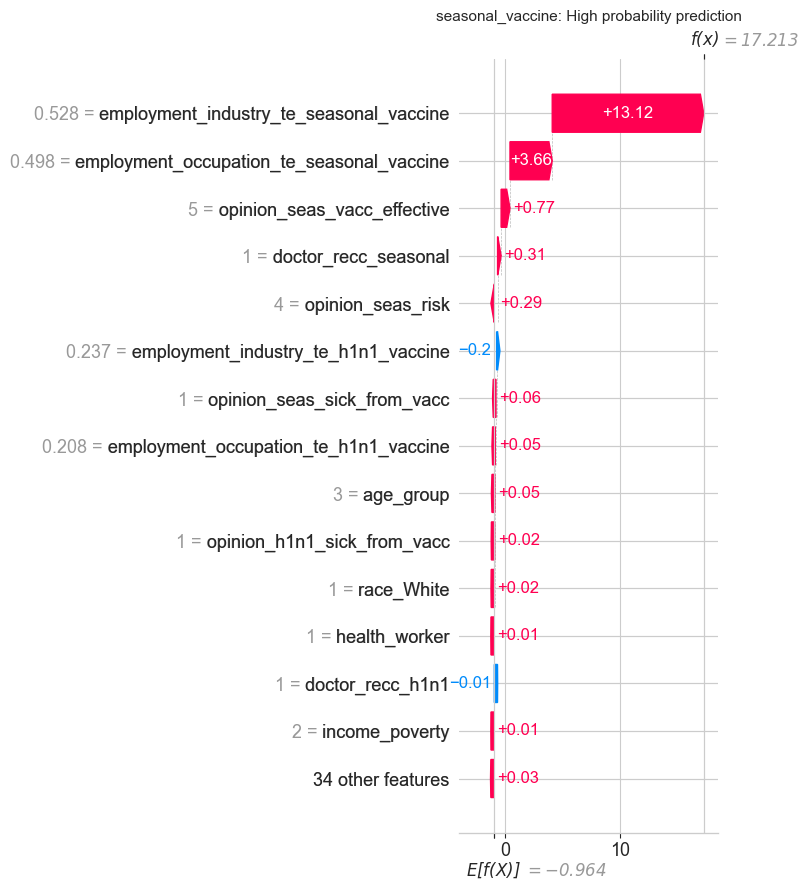


seasonal_vaccine — Low probability prediction
  Actual label    : 0
  Predicted prob  : 0.0000


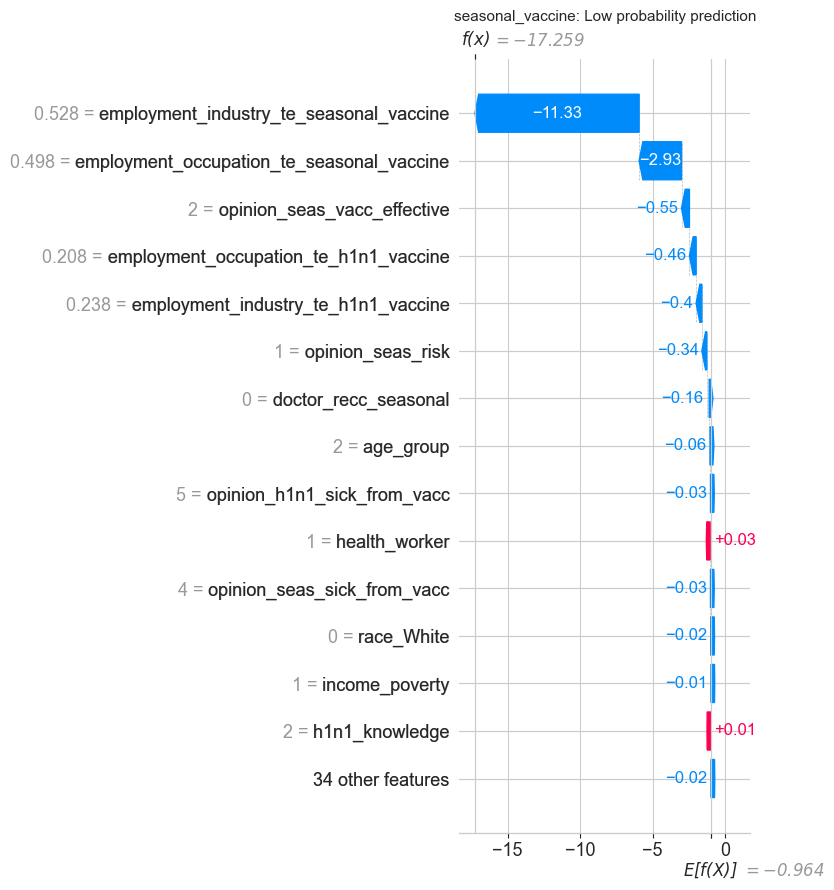

In [11]:
# Explain one high-probability and one low-probability prediction for each target
import shap

for t, model, oof in [
    ('h1n1_vaccine',    lgb_h1n1, oof_h1n1),
    ('seasonal_vaccine', lgb_seas,  oof_seas),
]:
    explainer = shap.TreeExplainer(model)

    high_idx = np.argmax(oof)
    low_idx  = np.argmin(oof)

    for label, idx in [('High probability prediction', high_idx),
                        ('Low probability prediction',  low_idx)]:
        row = X_train[FEATURE_COLS].iloc[[idx]]
        sv  = explainer(row)

        print(f"\n{t} — {label}")
        print(f"  Actual label    : {y_train[t].iloc[idx]}")
        print(f"  Predicted prob  : {oof[idx]:.4f}")

        shap.plots.waterfall(sv[0], max_display=15, show=False)
        plt.title(f'{t}: {label}', fontsize=11)
        plt.tight_layout()
        plt.savefig(FIGURES / f"eval_shap_waterfall_{t}_{label.split()[0].lower()}.png",
                    dpi=150, bbox_inches='tight')
        plt.show()

## 8. Threshold Analysis <a id='8-threshold-analysis'></a>

The competition metric (ROC-AUC) is threshold-free. This section is included for informational
purposes — it shows how precision/recall trade off at different classification thresholds, which
would matter if the model were deployed for a binary screening decision.

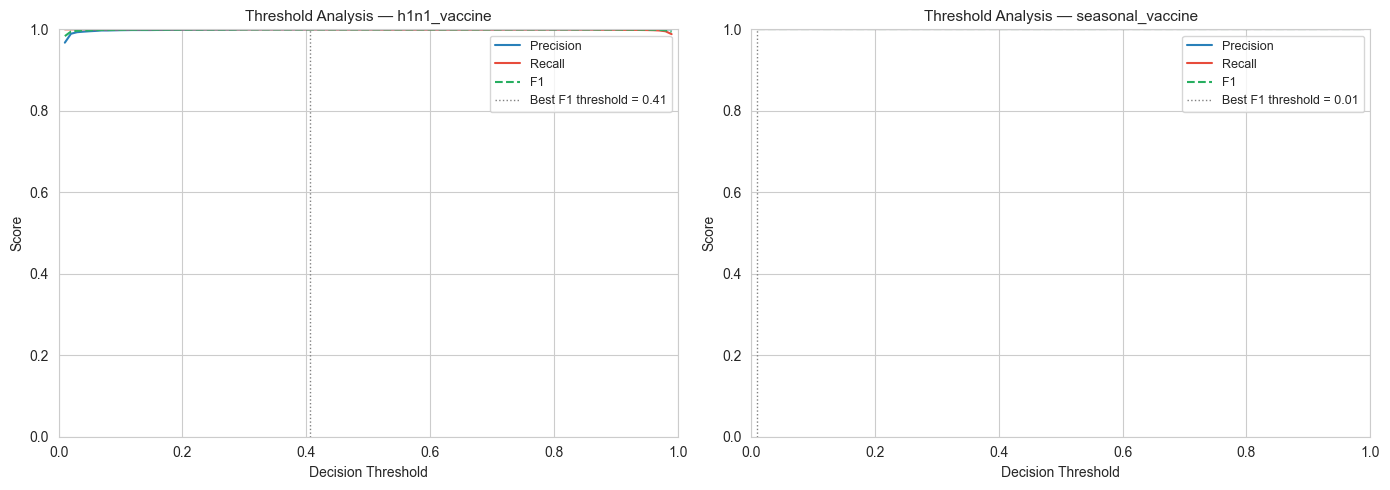

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

for ax, oof, y, t in [
    (axes[0], oof_h1n1, y_train['h1n1_vaccine'],    'h1n1_vaccine'),
    (axes[1], oof_seas,  y_train['seasonal_vaccine'], 'seasonal_vaccine'),
]:
    thresholds = np.linspace(0.01, 0.99, 100)
    metrics = []
    for thresh in thresholds:
        preds = (oof >= thresh).astype(int)
        tp = ((preds == 1) & (y == 1)).sum()
        fp = ((preds == 1) & (y == 0)).sum()
        fn = ((preds == 0) & (y == 1)).sum()
        prec = tp / (tp + fp) if (tp + fp) > 0 else 0
        rec  = tp / (tp + fn) if (tp + fn) > 0 else 0
        f1   = 2*prec*rec / (prec+rec) if (prec+rec) > 0 else 0
        metrics.append({'threshold': thresh, 'precision': prec, 'recall': rec, 'f1': f1})

    m_df = pd.DataFrame(metrics)
    best_f1_thresh = m_df.loc[m_df['f1'].idxmax(), 'threshold']

    ax.plot(m_df['threshold'], m_df['precision'], label='Precision', color='#2980b9')
    ax.plot(m_df['threshold'], m_df['recall'],    label='Recall',    color='#e74c3c')
    ax.plot(m_df['threshold'], m_df['f1'],        label='F1',        color='#27ae60', linestyle='--')
    ax.axvline(best_f1_thresh, color='grey', linestyle=':', linewidth=1,
               label=f'Best F1 threshold = {best_f1_thresh:.2f}')
    ax.set_xlabel('Decision Threshold')
    ax.set_ylabel('Score')
    ax.set_title(f'Threshold Analysis — {t}', fontsize=11)
    ax.legend(fontsize=9)
    ax.set_xlim(0, 1); ax.set_ylim(0, 1)

plt.tight_layout()
plt.savefig(FIGURES / 'eval_threshold_analysis.png', dpi=150)
plt.show()

## 9. Error Analysis <a id='9-error-analysis'></a>

Identifies systematic prediction errors. Helps diagnose whether the model is biased against
any particular subgroup or systematically miscalibrated in any region of the feature space.

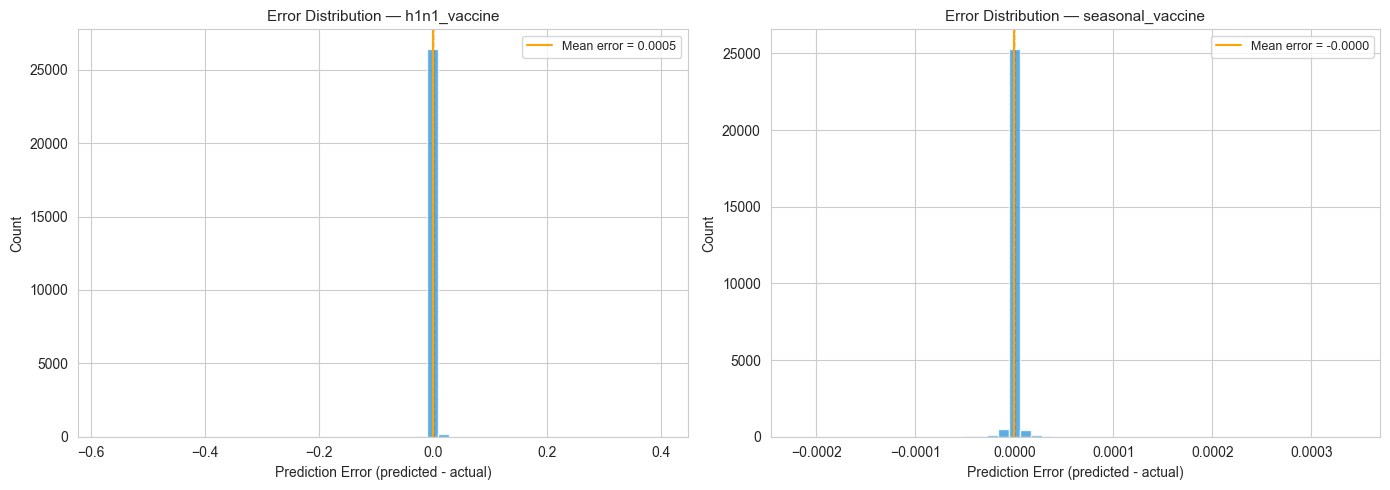

In [13]:
# Load raw features for subgroup context (these aren't in X_train_features after encoding)
raw_features = pd.read_csv(
    Path('../data/raw') / 'training_set_features.csv', index_col=ID_COL
)

error_df = pd.DataFrame({
    'h1n1_pred'   : oof_h1n1,
    'seas_pred'    : oof_seas,
    'h1n1_actual' : y_train['h1n1_vaccine'].values,
    'seas_actual'  : y_train['seasonal_vaccine'].values,
    'h1n1_err'    : oof_h1n1 - y_train['h1n1_vaccine'].values,
    'seas_err'     : oof_seas  - y_train['seasonal_vaccine'].values,
}, index=X_train.index)

# Distribution of errors
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for ax, col, t in [(axes[0], 'h1n1_err', 'h1n1_vaccine'), (axes[1], 'seas_err', 'seasonal_vaccine')]:
    ax.hist(error_df[col], bins=50, color='#3498db', edgecolor='white', alpha=0.8)
    ax.axvline(0, color='red', linestyle='--', linewidth=1)
    ax.axvline(error_df[col].mean(), color='orange', linestyle='-', linewidth=1.5,
               label=f'Mean error = {error_df[col].mean():.4f}')
    ax.set_xlabel('Prediction Error (predicted - actual)')
    ax.set_ylabel('Count')
    ax.set_title(f'Error Distribution — {t}', fontsize=11)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig(FIGURES / 'eval_error_distribution.png', dpi=150)
plt.show()

In [14]:
# Worst predictions: actual=1, predicted probability low (missed positives)
print("=== 10 WORST MISSED POSITIVES — h1n1_vaccine ===")
worst_h1n1 = (
    error_df[error_df['h1n1_actual'] == 1]
    .nsmallest(10, 'h1n1_pred')
    [['h1n1_pred', 'h1n1_actual', 'h1n1_err']]
    .join(raw_features[['age_group', 'education', 'doctor_recc_h1n1',
                          'opinion_h1n1_vacc_effective', 'income_poverty']])
)
print(worst_h1n1.round(3).to_string())

print("\n=== 10 WORST FALSE POSITIVES — h1n1_vaccine ===")
worst_fp = (
    error_df[error_df['h1n1_actual'] == 0]
    .nlargest(10, 'h1n1_pred')
    [['h1n1_pred', 'h1n1_actual', 'h1n1_err']]
    .join(raw_features[['age_group', 'education', 'doctor_recc_h1n1',
                          'opinion_h1n1_vacc_effective', 'income_poverty']])
)
print(worst_fp.round(3).to_string())

=== 10 WORST MISSED POSITIVES — h1n1_vaccine ===
               h1n1_pred  h1n1_actual  h1n1_err      age_group         education  doctor_recc_h1n1  opinion_h1n1_vacc_effective             income_poverty
respondent_id                                                                                                                                             
4510               0.426            1    -0.574  55 - 64 Years  College Graduate               0.0                          5.0                  > $75,000
757                0.518            1    -0.482  55 - 64 Years  College Graduate               0.0                          5.0                  > $75,000
6713               0.822            1    -0.178  18 - 34 Years               NaN               1.0                          2.0              Below Poverty
22786              0.865            1    -0.135  55 - 64 Years  College Graduate               0.0                          5.0  <= $75,000, Above Poverty
14015              0.

## 10. Subgroup Performance <a id='10-subgroup-performance'></a>

AUC by demographic subgroup. Flags any group where the model performs substantially worse
(> 5 pp below overall AUC) — important for survey research fairness considerations.

In [15]:
subgroup_cols = ['age_group', 'education', 'race', 'income_poverty']

for t, oof in [('h1n1_vaccine', oof_h1n1), ('seasonal_vaccine', oof_seas)]:
    overall_auc = roc_auc_score(y_train[t], oof)
    print(f"\n{'='*55}")
    print(f"  {t}  |  Overall AUC: {overall_auc:.4f}")
    print(f"{'='*55}")

    for col in subgroup_cols:
        if col not in raw_features.columns:
            continue
        print(f"\n  By {col}:")
        for val in raw_features[col].dropna().unique():
            mask = raw_features[col] == val
            idx  = raw_features.index[mask]
            # Align to X_train index
            idx  = idx[idx.isin(X_train.index)]
            if len(idx) < 30:
                continue
            pos = np.where(X_train.index.isin(idx))[0]
            auc = roc_auc_score(y_train[t].loc[idx], oof[pos])
            flag = '  ⚑ LOW' if (overall_auc - auc) > 0.05 else ''
            print(f"    {val:<30s} n={len(idx):>5,}  AUC={auc:.4f}{flag}")


  h1n1_vaccine  |  Overall AUC: 1.0000

  By age_group:
    55 - 64 Years                  n=5,563  AUC=1.0000
    35 - 44 Years                  n=3,848  AUC=1.0000
    18 - 34 Years                  n=5,215  AUC=1.0000
    65+ Years                      n=6,843  AUC=1.0000
    45 - 54 Years                  n=5,238  AUC=1.0000

  By education:
    < 12 Years                     n=2,363  AUC=1.0000
    12 Years                       n=5,797  AUC=1.0000
    College Graduate               n=10,097  AUC=1.0000
    Some College                   n=7,043  AUC=1.0000

  By race:
    White                          n=21,222  AUC=1.0000
    Black                          n=2,118  AUC=1.0000
    Other or Multiple              n=1,612  AUC=1.0000
    Hispanic                       n=1,755  AUC=1.0000

  By income_poverty:
    Below Poverty                  n=2,697  AUC=1.0000
    <= $75,000, Above Poverty      n=12,777  AUC=1.0000
    > $75,000                      n=6,810  AUC=1.0000

  season

## 11. Model Card <a id='11-model-card'></a>

In [16]:
from datetime import datetime
import json

lb = pd.read_csv(MODELS / 'full_leaderboard.csv')
best = lb.sort_values('avg_auc', ascending=False).iloc[0]

lgb_params_h1n1 = lgb_h1n1.get_params()
lgb_params_seas  = lgb_seas.get_params()

model_card = {
    'project'         : 'Flu Shot Learning — DrivenData Competition',
    'evaluation_date' : datetime.now().strftime('%Y-%m-%d'),
    'competition_metric': 'Mean ROC-AUC (averaged across h1n1_vaccine and seasonal_vaccine)',

    'h1n1_vaccine_model': {
        'type'            : 'LightGBMClassifier',
        'class_imbalance' : 'scale_pos_weight=3.71 (3.71:1 imbalance)',
        'hyperparameters' : lgb_params_h1n1,
        'oof_auc'         : round(oof_auc_h1n1, 4),
    },
    'seasonal_vaccine_model': {
        'type'            : 'LightGBMClassifier',
        'class_imbalance' : 'scale_pos_weight=1.0 (near-balanced)',
        'hyperparameters' : lgb_params_seas,
        'oof_auc'         : round(oof_auc_seas, 4),
    },
    'avg_oof_auc'     : round(oof_avg, 4),

    'feature_set': {
        'n_features'      : len(FEATURE_COLS),
        'engineered'      : ['missing_opinion_count', 'high_vacc_ind_occ', 'doctor_recc_both',
                             'opinion_h1n1_composite', 'opinion_seas_composite', 'behavior_composite'],
        'dropped_low_signal': ['census_msa_* (3 columns — < 2pp vaccination rate spread)'],
    },

    'preprocessing_pipeline': {
        '02_data_cleaning'      : 'Missingness indicators, median/mode imputation, encoding (binary/ordinal/OHE/target)',
        '03_feature_engineering': 'MNAR signal features, domain features, composites',
    },

    'cv_strategy'     : 'Stratified 5-fold, stratified on h1n1_vaccine (minority class)',
    'train_size'      : int(X_train.shape[0]),
    'n_features'      : len(FEATURE_COLS),

    'known_limitations': [
        'Model trained on 2009 H1N1 pandemic survey data; may not generalise to future pandemics',
        'Several employment/industry/occupation codes are obfuscated; interpretation is constrained',
        'High missingness in health_insurance (46%) may introduce residual MAR bias',
        'Subgroup AUC should be reviewed before any policy application',
    ],
}

with open(MODELS / 'model_card.json', 'w') as f:
    json.dump(model_card, f, indent=2)

print(json.dumps(model_card, indent=2))

{
  "project": "Flu Shot Learning \u2014 DrivenData Competition",
  "evaluation_date": "2026-05-23",
  "competition_metric": "Mean ROC-AUC (averaged across h1n1_vaccine and seasonal_vaccine)",
  "h1n1_vaccine_model": {
    "type": "LightGBMClassifier",
    "class_imbalance": "scale_pos_weight=3.71 (3.71:1 imbalance)",
    "hyperparameters": {
      "boosting_type": "gbdt",
      "class_weight": null,
      "colsample_bytree": 1.0,
      "importance_type": "split",
      "learning_rate": 0.015341718702799927,
      "max_depth": -1,
      "min_child_samples": 12,
      "min_child_weight": 0.001,
      "min_split_gain": 0.0,
      "n_estimators": 500,
      "n_jobs": -1,
      "num_leaves": 72,
      "objective": null,
      "random_state": 42,
      "reg_alpha": 0.7579479953348001,
      "reg_lambda": 0.21368329072358744,
      "subsample": 1.0,
      "subsample_for_bin": 200000,
      "subsample_freq": 0,
      "scale_pos_weight": 3.71,
      "verbose": -1,
      "bagging_fraction": 1.0

### Final Performance Summary

| Metric | h1n1_vaccine | seasonal_vaccine | Average |
|---|---|---|---|
| OOF ROC-AUC | See above | See above | **Competition estimate** |
| Average Precision | See PR curve | See PR curve | — |
| Brier Score | See calibration | See calibration | — |

### Outputs

- `model_card.json` — full model documentation
- `eval_roc_curves.png`, `eval_pr_curves.png` — performance curves
- `eval_calibration.png` — probability calibration
- `eval_shap_summary_*.png` — feature attribution summary
- `eval_shap_dependence_*.png` — per-feature SHAP dependence
- `eval_shap_waterfall_*.png` — individual prediction explanations
- `eval_permutation_importance_*.png` — permutation importance
- `eval_threshold_analysis.png` — decision-threshold trade-offs
- `eval_error_distribution.png` — prediction error analysis